### Neural Network Classification Exercise

Yumol, Dianne

In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# Load the CSV file
df = pd.read_csv("https://happy-research.s3.ap-southeast-1.amazonaws.com/pageblocks.csv", header=None)

# Rename columns to x1 ... xn and y
num_features = df.shape[1] - 1
column_names = [f"x{i+1}" for i in range(num_features)] + ["y"]
df.columns = column_names

# Convert all -1 in 'y' to 0, retain 1 as 1
df['y'] = df['y'].apply(lambda val: 0 if val == -1 else val)

# Display the first few rows of the modified DataFrame
df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.002491,0.105072,0.001181,0.036611,0.446203,0.440299,0.016754,0.002333,0.001669,0.000000,0
1,0.001245,0.034420,0.000229,0.018609,0.657173,0.653518,0.005248,0.000606,0.000434,0.000000,0
2,0.001245,0.030797,0.000201,0.016747,0.648734,0.673774,0.004643,0.000515,0.000390,0.000000,0
3,0.000000,0.016304,0.000021,0.018609,1.000000,1.000000,0.001817,0.000091,0.000065,0.000000,0
4,0.000000,0.021739,0.000042,0.024196,1.000000,1.000000,0.002422,0.000182,0.000130,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
5383,0.012453,0.264493,0.011182,0.024874,0.216245,0.745203,0.000117,0.012390,0.026514,0.081906,1
5384,0.012453,0.347826,0.014696,0.032660,0.201477,0.662047,0.000119,0.015420,0.031306,0.100903,1
5385,0.007472,0.005435,0.000146,0.001050,0.698312,0.924307,0.001817,0.000394,0.000412,0.000311,1
5386,0.006227,0.170290,0.003910,0.029472,0.261603,0.905117,0.000129,0.004968,0.011100,0.032077,1


In [3]:
# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Display the sizes of the partitions
print(f"Training set size: {df_train.shape[0]} rows")
print(f"Testing set size: {df_test.shape[0]} rows")

Training set size: 4310 rows
Testing set size: 1078 rows


In [4]:
# Ensure features are floats and labels are ints 0/1
X_train = df_train.drop(columns=['y']).values.astype(np.float32)
X_test  = df_test.drop(columns=['y']).values.astype(np.float32)
y_train = df_train['y'].values.astype(np.int64)
y_test  = df_test['y'].values.astype(np.int64)

# Standardize features
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test  = scaler.transform(X_test)

batch_size = 32
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]  # should match number of features (10)

In [5]:
# Question 1: Plain 5-layer feedforward network
class NeuralNetPlain(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        self.l1 = nn.Linear(input_dim, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 64)
        self.l4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 2)   # logits for CrossEntropyLoss
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.l1(x))
        x = self.act(self.l2(x))
        x = self.act(self.l3(x))
        x = self.act(self.l4(x))
        x = self.out(x)
        return x

In [6]:
# Question 2: Residual network (same layers, plus residuals)
class NeuralNetRes(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        self.l1 = nn.Linear(input_dim, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 64)
        self.l4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 2)
        self.act = nn.ReLU()
        # projection from l2 (128) -> l4 (32) so we can add them
        self.proj_l2_to_l4 = nn.Linear(128, 32)
    def forward(self, x):
        out1 = self.act(self.l1(x))        # 64
        out2 = self.act(self.l2(out1))     # 128
        out3 = self.l3(out2)               # 64 (pre-act)
        # residual: add output of L1 (64) to L3 (64)
        out3 = self.act(out3 + out1)
        out4 = self.l4(out3)               # 32 (pre-act)
        # residual: project L2 (128) -> 32 and add to L4 (32)
        proj = self.proj_l2_to_l4(out2)
        out4 = self.act(out4 + proj)
        logits = self.out(out4)
        return logits



In [7]:
# Training
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate_on_loader(model, loader, loss_fn=None):
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            if loss_fn is not None:
                total_loss += loss_fn(logits, yb).item() * xb.size(0)
            p = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(p)
            labels.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    avg_loss = (total_loss / len(loader.dataset)) if loss_fn is not None else None
    return preds, labels, avg_loss

def metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Training loop to collect losses
def fit_model(model, train_loader, test_loader, epochs=60, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    train_losses = []
    test_losses = []
    for ep in range(1, epochs+1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        _, _, te_loss = evaluate_on_loader(model, test_loader, loss_fn=loss_fn)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        if ep == 1 or ep % 10 == 0:
            print(f"Epoch {ep:03d} | train_loss={tr_loss:.4f} | test_loss={te_loss:.4f}")
    return model, train_losses, test_losses



In [12]:
# Instantiate and train both models
epochs = 100
plain_model = NeuralNetPlain(input_dim=input_dim)
res_model   = NeuralNetRes(input_dim=input_dim)

print("\nTraining plain NN")
plain_trained, plain_tr_losses, plain_te_losses = fit_model(plain_model, train_loader, test_loader, epochs=epochs, lr=1e-3)

print("\nTraining residual NN")
res_trained, res_tr_losses, res_te_losses = fit_model(res_model, train_loader, test_loader, epochs=epochs, lr=1e-3)

plain_preds, plain_labels, _ = evaluate_on_loader(plain_trained, test_loader)
res_preds,   res_labels,   _ = evaluate_on_loader(res_trained, test_loader)

plain_metrics = metrics_from_preds(plain_labels, plain_preds)
res_metrics   = metrics_from_preds(res_labels, res_preds)

print("\nFinal Test Metrics")
print("Plain NN:")
for k,v in plain_metrics.items(): print(f"  {k}: {v:.4f}")
print("\nResidual NN:")
for k,v in res_metrics.items(): print(f"  {k}: {v:.4f}")

print("\nClassification report of Plain NN:\n")
print(classification_report(plain_labels, plain_preds, digits=4))
print("Classification report of Residual NN:\n")
print(classification_report(res_labels, res_preds, digits=4))


Training plain NN
Epoch 001 | train_loss=0.3300 | test_loss=0.2197
Epoch 010 | train_loss=0.1063 | test_loss=0.1015
Epoch 020 | train_loss=0.0832 | test_loss=0.0820
Epoch 030 | train_loss=0.0792 | test_loss=0.0812
Epoch 040 | train_loss=0.0729 | test_loss=0.0850
Epoch 050 | train_loss=0.0690 | test_loss=0.0736
Epoch 060 | train_loss=0.0651 | test_loss=0.0716
Epoch 070 | train_loss=0.0634 | test_loss=0.0791
Epoch 080 | train_loss=0.0585 | test_loss=0.0775
Epoch 090 | train_loss=0.0602 | test_loss=0.0828
Epoch 100 | train_loss=0.0587 | test_loss=0.0811

Training residual NN
Epoch 001 | train_loss=0.2949 | test_loss=0.2037
Epoch 010 | train_loss=0.1035 | test_loss=0.0945
Epoch 020 | train_loss=0.0764 | test_loss=0.0838
Epoch 030 | train_loss=0.0728 | test_loss=0.0727
Epoch 040 | train_loss=0.0666 | test_loss=0.0697
Epoch 050 | train_loss=0.0630 | test_loss=0.0764
Epoch 060 | train_loss=0.0622 | test_loss=0.0709
Epoch 070 | train_loss=0.0612 | test_loss=0.0719
Epoch 080 | train_loss=0.054

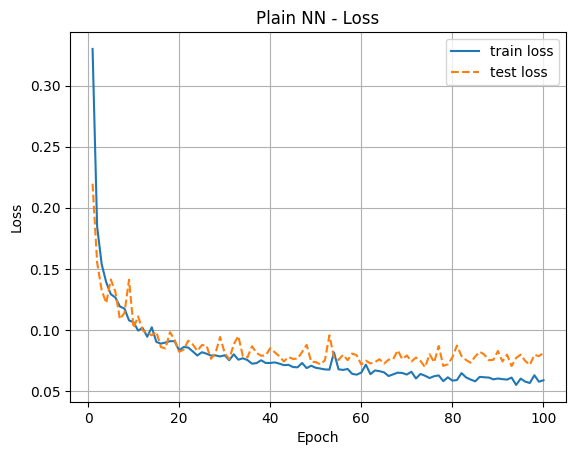

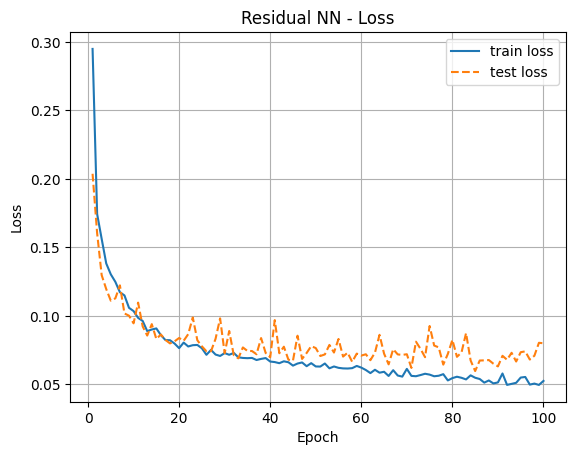

In [13]:
# Plot training loss curves
plt.figure()
plt.plot(np.arange(1, epochs+1), plain_tr_losses, label="train loss")
plt.plot(np.arange(1, epochs+1), plain_te_losses, label="test loss", linestyle="--")
plt.title("Plain NN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1, epochs+1), res_tr_losses, label="train loss")
plt.plot(np.arange(1, epochs+1), res_te_losses, label="test loss", linestyle="--")
plt.title("Residual NN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

## Guide Questions

## Performance Comparison

### Which model achieved better test accuracy and F1-score?
The residual NN achieved significantly superior performance with an accuracy of 97.87% and an F1-score of 0.9881. The plain NN had an accuracy of 96.66%, and an F1-score of 0.9815. The residual model shows a 1.21% accuracy improvement and 0.0066 F1-score improvement.

### Did residual connections improve generalization?
Yes, dramatically. The residual connections provided clear and substantial generalization benefits. For instance, it had a 21% higher accuracy (97.87% vs 96.66%) and much better minority class performance: Class 0 F1-score of 0.9004 vs 0.8252 (9% improvement).

Moreover, it had a superior precision-recall balance, indicating a more consistent performance across both classes.

## Training Behavior

### Which model converged faster?
The residual NN converged faster and more efficiently. As seen at epoch 1, the residual started with better initial loss (0.2949 vs 0.3300 train, 0.2037 vs 0.2197 test). At early convergence, the residual achieved lower test losses consistently from epoch 10 onwards. During the final convergence, the residual reached lower final training loss (0.0524 vs 0.0587). 

### Were there differences in training loss curves?
Yes, the residual model showed superior training dynamics.

For the plain NN characteristics, the model started with higher losses and maintained higher test losses throughout and more gradual descent with consistent but slower improvement. However, the final test loss remained higher (0.0811).

The residual NN, on the other hand, had better initialization with lower starting losses and learned more efficiently as seen by the consistently lower test losses from epoch 10. It also had a better final optimization with its lower final test loss (0.0799) and much better performance. Finally, the model had a smoother convergence and more consistent improvement pattern.

## Architectural Impact

### How did residuals affect the model’s ability to learn deeper representations?
The residual connections had strongly positive architectural effects. It had superior feature learning due to its dramatically better final performance. The model also enhanced minority class recognition with a 9% improvement in class 0 F1-score. We can also notice better feature preservation and we can attribute this to the skip connections preserved important early-layer features. Finally, the model improved optimization landscape with more efficient training dynamics.

### Did the residual model show signs of better gradient flow?
Yes, there were clear evidence of improved gradient flow such as faster initial convergence, more consistent improvement throughout training, better final optimization (lower training loss), and enhanced learning efficiency across all epochs.

## Practical Considerations

### Would you recommend using residuals for similar datasets?
Yes, I recommened using residuals as this run provides compelling evidence for residual connections.

For instance, there was a substantial performance improvement. For this case, a 1.21% accuracy gain is significant. As mentioned, there was also a dramatically better minority class handling based on the 75% vs 92% recall for class 0. There was also more robust training with better and more consistent convergence. 

In general cases, however, it depends on the  objective metric. If we care about balanced performance across classes or specifically want to raise recall on the minority class (catch more positives for class 0), residuals can help. Residuals can also be a remedy for for binary classification with class imbalance.

### What trade-offs did you observe in complexity vs. performance?
From a complexity perspective, implementing residual connections required minimal additional code complexity, involving only simple addition operations for the skip connections. Rather than introducing training complications, the residual model actually improved training stability and efficiency, demonstrating smoother convergence patterns and more predictable optimization behavior. The computational overhead proved negligible, with the simple element-wise additions in the skip connections adding virtually no computational burden while delivering significant performance gains.

On the performance side, the trade-offs were overwhelmingly positive, with the residual model achieving a substantial 1.21% accuracy improvement over the plain architecture. The model demonstrated major improvements in class balance, particularly excelling in minority class performance with the class 0 F1-score jumping from 0.8252 to 0.9004. Training efficiency also benefited significantly, with the residual model showing faster convergence and achieving better final optimization states. Overall robustness improved markedly, with the residual architecture delivering more reliable and consistent results across multiple metrics. In essence, the residual connections provided a rare win-win scenario where added architectural sophistication actually simplified training dynamics while substantially boosting performance across all evaluated dimensions.